Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Covertype_p_1_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Covertype_p_1_3.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Covertype_p_1_5.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Covertype_p_1_7.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Covertype_p_2_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Example2D_p_1_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Example2D_p_1_3.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Example2D_p_1_5.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Example2D_p_1_7.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Example2D_p_2_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Iris_p_1_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Iris_p_1_3.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Iris_p_1_5.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Iris_p_1_7.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_Iris_p_2_0.png
Gespeichert: Plots\Lewis_vs_l2lp\ratio_hist_KDDCup_p_1_0.png
Gesp

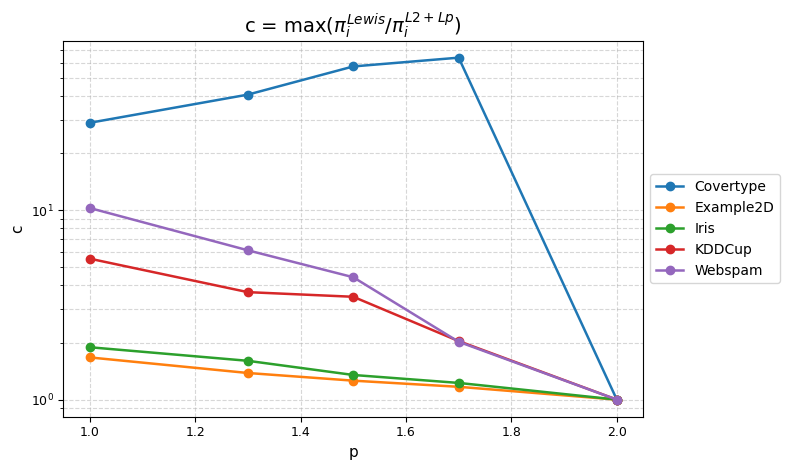

Gespeichert: Plots\Lewis_vs_l2lp\c_values_l2lp_p_bis_2.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PICKLE_PATH = Path("Plots") / "probability_distributions.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)
df_probs = df_probs[df_probs["p"].isin([1.0, 1.3, 1.5, 1.7, 2.0])].copy()

OUT_DIR = Path("Plots") / "Lewis_vs_l2lp"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("Tabellen")
TABLE_DIR.mkdir(exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 10

EPS = 1e-300


def choose_ratio_bins(ratio, n_bins=60):
    ratio = np.asarray(ratio, dtype=float)
    ratio = ratio[np.isfinite(ratio)]
    ratio = ratio[ratio > 0]

    rmin = float(max(np.min(ratio), 1e-6))
    rmax = float(max(np.max(ratio), rmin * 1.01))

    if rmax / rmin > 50:
        bins = np.logspace(np.log10(rmin), np.log10(rmax), n_bins)
        xscale = "log"
    else:
        bins = np.linspace(rmin, rmax, n_bins)
        xscale = "linear"

    # Include the true maximum safely in the last bin despite floating-point rounding.
    bins[-1] = np.nextafter(rmax, np.inf)

    return bins, xscale


rows_c = []

for _, row in df_probs.sort_values(["dataset", "p"]).iterrows():
    dataset_name = row["dataset"]
    p_val = float(row["p"])
    p_str = str(p_val).replace(".", "_")

    ratio = np.maximum(row["prob_lewis_weight"], EPS) / np.maximum(row["prob_l2_lp_leverage_score"], EPS)
    ratio = ratio[np.isfinite(ratio)]

    c_value = float(np.max(ratio))
    rows_c.append({
        "dataset": dataset_name,
        "p": p_val,
        "c": c_value,
        "ratio_mean": float(np.mean(ratio)),
        "ratio_median": float(np.median(ratio)),
    })

    bins, xscale = choose_ratio_bins(ratio, n_bins=60)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.hist(ratio, bins=bins)
    ax.set_xscale(xscale)
    ax.set_yscale("log")
    ax.axvline(c_value, color="tab:red", linestyle="--", linewidth=1.3, label=f"c = {c_value:.3f}")
    ax.set_title(f"{dataset_name} (p = {p_val})")
    ax.set_xlabel(r"$\pi^{Lewis}_i / \pi^{L2+Lp}_i$")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    fig.tight_layout()

    out_path = OUT_DIR / f"ratio_hist_{dataset_name}_p_{p_str}.png"
    fig.savefig(out_path, dpi=250, bbox_inches="tight")
    plt.close(fig)
    print("Gespeichert:", out_path)


df_c = pd.DataFrame(rows_c).sort_values(["dataset", "p"]).reset_index(drop=True)
df_c[["c", "ratio_mean", "ratio_median"]] = df_c[["c", "ratio_mean", "ratio_median"]].round(4)
df_c_export = df_c[["dataset", "p", "c"]].copy()

out_csv = TABLE_DIR / "Bestimmung_c_max_l2lp_p_bis_2.csv"
df_c_export.to_csv(out_csv, index=False)
print("CSV gespeichert:", out_csv)

out_stats_csv = TABLE_DIR / "Bestimmung_c_max_l2lp_statistik_p_bis_2.csv"
df_c.to_csv(out_stats_csv, index=False)
print("CSV gespeichert:", out_stats_csv)
print(df_c_export)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
for dataset_name in df_c["dataset"].unique():
    sub = df_c[df_c["dataset"] == dataset_name].sort_values("p")
    ax.plot(sub["p"], sub["c"], marker="o", linewidth=1.8, label=dataset_name)

ax.set_title(r"c = max($\pi^{Lewis}_i / \pi^{L2+Lp}_i$)")
ax.set_xlabel("p")
ax.set_ylabel("c")
ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()

out_path = OUT_DIR / "c_values_l2lp_p_bis_2.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Gespeichert:", out_path)
